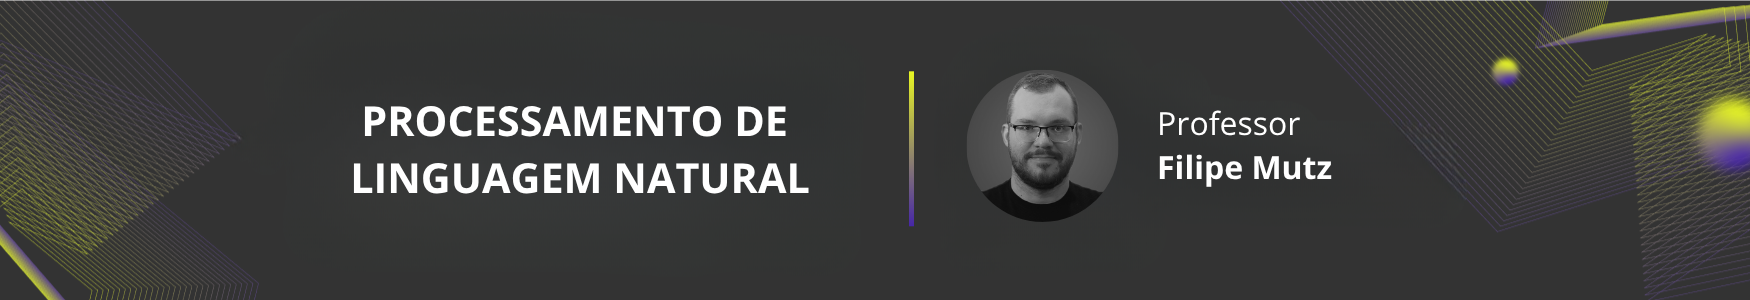

# 📝🤖 Classificação de Textos usando Bag-of-Words (BoW)


Os algoritmos de aprendizado de máquina estudados até agora assumem que dados de entrada dos modelos são vetores numéricos ou podem ser transformados neste formato via uma série de operações (e.g., transformar dados categóricos em vetores *one-hot*).  É natural assumir, portanto, que também teremos que transformar textos em uma representação vetorial. Existem diversas formas de fazer isto, sendo que as mais utilizadas atualmente são as representações por **Bag-of-Words** (BoW) - "saco de palavras", em português -  e **Text Embeddings**. O objetivo deste notebook é compreender o que é a representação por Bag-of-Words e como utilizá-la para transformar os documentos de um corpus em vetores. No processo, vamos conhecer alguns conceitos da área de processamento de linguagem natural e compreender como preprocessar dados textuais. A representação por Text Embeddings será estudada nas próximas semanas.


## Agenda

1. Representação Vetorial de Documentos com Bag-of-Words e TF-IDF
2. Como Calcular a Similaridade entre Documentos
3. Preprocessamento de Textos
4. Aplicação Prática no Treinamento de um Classificador

## Preparação

Instalação de bibliotecas necessárias para o notebook.

In [ ]:
!python -m pip install unidecode nltk spacy kagglehub tiktoken

## Fundamentação Teórica

### Representação Vetorial de Documentos com Bag-of-Words


A premissa central da representação vetorial de documentos com Bag-of-Words (BoW) é que **documentos que falam sobre o mesmo tópico tendem a usar as mesmas palavras**. Por exemplo, em textos sobre esportes é comum encontrar termos como "partida", "jogador", "time" ou "vencer", enquanto em textos sobre política é comum encontrar os temos "partido", "votar" ou "deputado".

Como ilustrado na figura abaixo, para transformar textos em vetores usando esta abordagem:
1. Identificam-se todas as palavras diferentes existentes no corpus. Este conjunto de palavras é comumente chamado de dicionário ou vocabulário.
2. Constroe-se a representação vetorial dos documentos contando a frequência das palavras no documento.


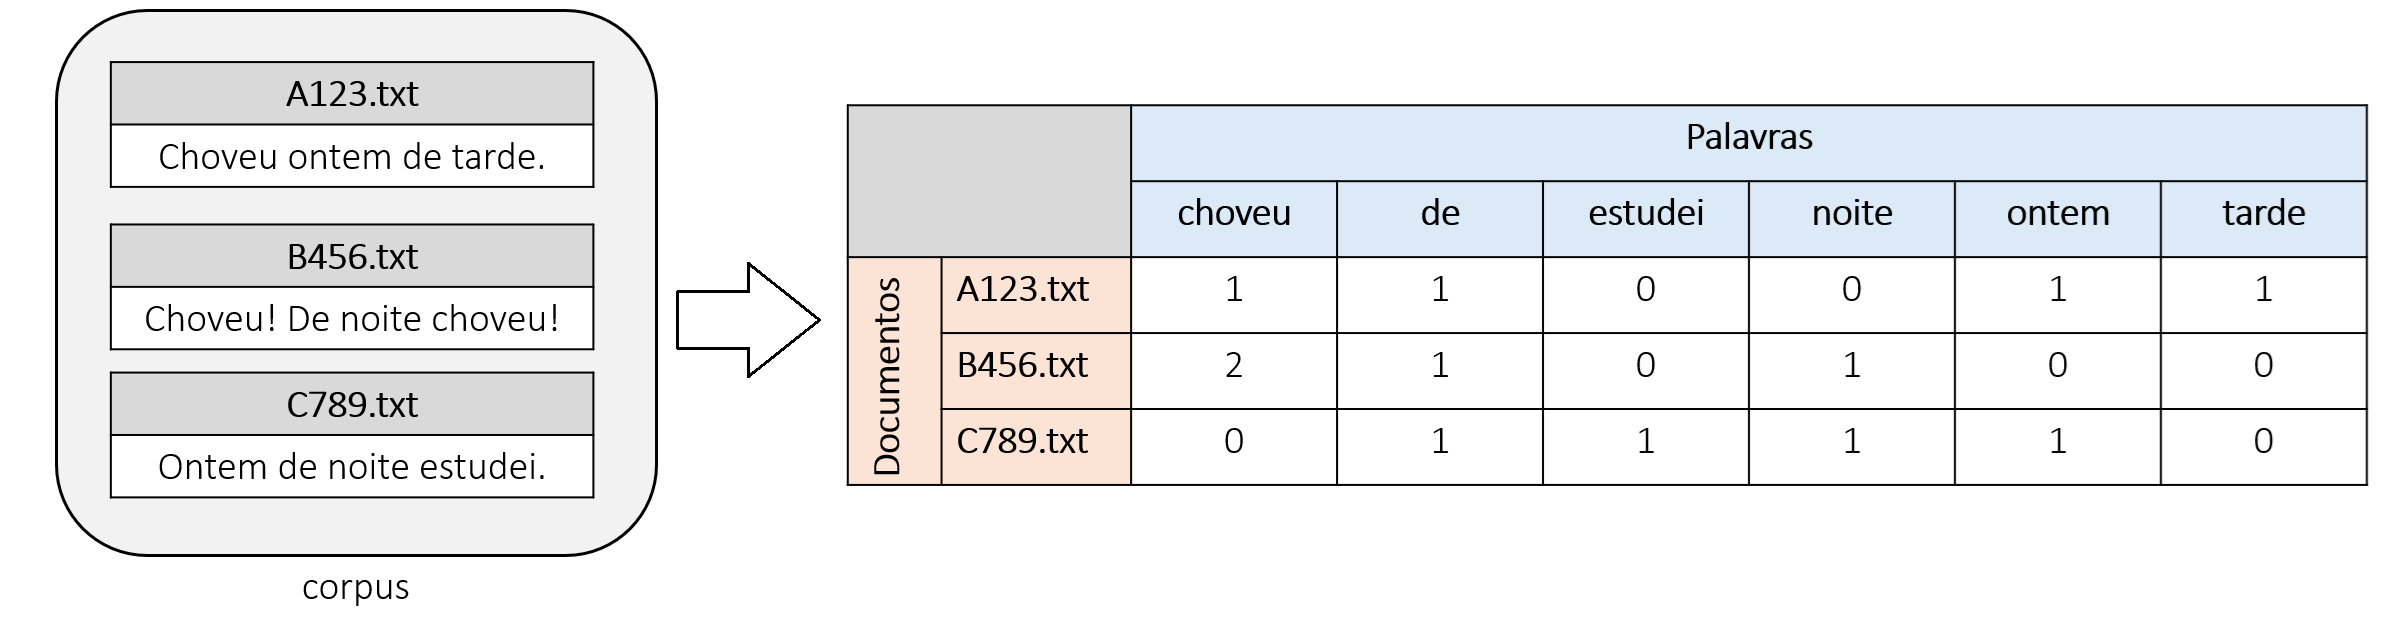

Portanto, as representações com BoW dos documentos de exemplo serão:

- A123.txt: "Choveu ontem de tarde." $\rightarrow$ $[1, 1, 0, 0, 1, 1]$.
- B456.txt: "Choveu! De noite choveu!" $\rightarrow$ $[2, 1, 0, 1, 0, 0]$.  
- C789.txt: "Ontem de noite estudei." $\rightarrow$ $[0, 1, 1, 1, 1, 0]$.


O BoW é dito um método de **análise semântica** por não considar outras características linguísticas dos textos como a sintaxe ou a posição relativa das palavras dentro de estruturas textuais como parágrafos ou sentenças. Para o BoW, as sentenças "Choveu ontem de tarde." e "tarde de Choveu ontem." são equivalentes.

### Outras Representações Vetoriais e o TF-IDF

Existem outras representações vetoriais de documentos além do BoW clássico.

Na representação **Binária/Booleana**, cada documento é transformado em um vetor binário, onde $1$ indica a presença de uma palavra e $0$ indica sua ausência. Nesta abordagem, se dois documentos possuem as mesmas palavras, independente de quantas vezes, eles são considerados próximos.




A representação por **Frequência de Termo-Frequência Inversa em Documentos** (*Term Frequency-Inverse Document Frequency* - TF-IDF) enfatiza palavras que são frequentes em grupos específicos de documentos e reduz a importância daquelas que são comuns em muitos documentos. Palavras que aparecem em quase todos os documentos, independente da classe, não ajudam a discriminar a categoria do documento.

Na representação por TF-IDF, ao invés dos vetores armazenarem a frequência dos termos, eles armazenam um peso por termo que é uma função da  frequência do termo no documento, mas também da frequência total do termo no corpus. O peso do termo $t$ no documento $d$ será dado por:

$$
\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \text{IDF}(t, D)
$$

onde

$$
\text{TF}(t, d): \text{Número de ocorrências de t em d}
$$

e

$$
\text{IDF}(t, D) = 1 + \log \frac{\text{1 + Número de documentos em D}}{1 + \text{Número de documentos contendo t}}
$$

O termo $\text{TF}$ premia as palavras que aparecem com frequência em um documento. Já o termo $\text{IDF}$ premia palavras que aparecem em um percentual pequeno de documentos.

O uso do $\log$ tem como objetivo reduzir a diferença entre os pesos. Por exemplo, um termo que aparece em $1$ documento de um corpus de $1000$ documentos, teria peso $1000$ sem o uso do $\log$, mas $\log(1000) \approx 6.91$. Isto é particularmente importante em bases de dados grandes.

Considerando os textos de exemplo utilizados para explicar o BoW, o IDF dos termos seria:

- *"choveu"*: 2 de 3 documentos $\rightarrow \text{IDF} = 1 + \log \left[ (3 + 1) / (2 + 1) \right] = 1.28 $.
- *"de"*: 3 de 3 documentos $\rightarrow \text{IDF} = 1 + \log \left[ (3 + 1) / (3 + 1) \right] = 1.00 $.
- *"estudei"*: 1 de 3 documentos $\rightarrow \text{IDF} = 1 + \log \left[ (3 + 1) / (1 + 1) \right] = 1.69 $.
- *"noite"*: 2 de 3 documentos $\rightarrow \text{IDF} = 1 + \log \left[ (3 + 1) / (2 + 1) \right] = 1.28 $.
- *"ontem"*: 2 de 3 documentos $\rightarrow \text{IDF} = 1 + \log \left[ (3 + 1) / (2 + 1) \right] = 1.28 $.
- *"tarde"*: 1 de 3 documentos $\rightarrow \text{IDF} = 1 + \log \left[ (3 + 1) / (1 + 1) \right] = 1.69 $.

Quanto maior a base de dados,  mais proeminentes se tornam os pesos. Por exemplo, uma palavra que aparece em $50$ documentos de uma base de $1000$ documentos, teria $\text{IDF} = 1 + \log (1001 / 51) = 3.98$.

### Medidas de Similaridade entre Documentos

Para realizar a classificação ou clusterização de documentos, é necessário saber como medir a similaridade ou a distância entre seus respectivos vetores. Existem várias formas de comparar vetores de documentos e a seguir apresentamos as duas mais comuns.

#### Distância Euclidiana

Considere dois vetores $\mathbf{v}$ e $\mathbf{w}$ com $n$ posições, onde $n$ é o número de palavras no dicionário. Uma forma de avaliar o quão distintos são dois documentos é calculando a **distância euclidiana** entre seus vetores:

$$
d(\mathbf{v}, \mathbf{w}) = \sqrt{\sum_{i=0}^n (v_i - w_i)^2}
$$

Esta operação vai medir o quão diferente são as frequências das palavras nos dois documentos. Ela tem a vantagem de ser simples e fácil de interpretar, mas é influenciada pelo tamanho dos documentos. Documentos com muitas palavras terão valores mais altos de frequência do que documentos mais curtos. Assim, mesmo se dois documentos usarem as mesmas palavras, a distância entre eles pode ser considerada grande dependendo da quantidade de vezes que os termos aparecem.

#### Cosseno

Uma alternativa à distância euclidiana é o **cosseno do ângulo entre os vetores**:

$$
\cos(\mathbf{v}, \mathbf{w}) = \frac{\mathbf{v} \cdot \mathbf{w}}{||\mathbf{v}||\ ||\mathbf{w}||}
$$

O valor do cosseno será $1$ se o ângulo entre os vetores for $0$ e, neste caso, dizemos que existe 100\% de similaridade entre os documentos. Note que o ângulo é influenciado apenas pela frequência *relativa* entre os termos, isto é, ele não muda se multiplicarmos um dos vetores por uma constante.

#### ⚠️ Atenção ⚠️

- Para que o cálculo de distância/similaridade entre documentos faça sentido, **os índices das palavras devem ser os mesmos para todos os vetores de documentos**. A frequência de uma dada posição deve se referir à uma mesma palavra em todos os documentos.

- Embora o cosseno seja teoricamente preferível em relação à distância euclidiana, na prática ambas apresentam boa performance em alguns datasets. É uma boa prática considerar que a medida de distância/similaridade é um hiperparâmetro a ser ajustado.


### Preprocessamento dos Textos

A seguir, veremos algumas técnicas de preprocessamento de textos tipicamente aplicadas em tarefas de processamento de linguagem natural.

O objetivo desta seção é apresentar o conjunto de técnicas e prover uma intuição do porquê utilizá-las, contudo tenha em mente que não é necessário aplicar todas elas *SEMPRE*. A opção por usar uma ou outra técnica depende da tarefa a ser resolvida e do método sendo utilizado. Ao abordar uma nova tarefa ou um novo método, é sempre uma boa idéia consultar artigos e a documentação de bibliotecas para conhecer quais técnicas de preprocessamento são normalmente usadas no contexto.


Para ilustrar estes conceitos vamos utilizar a frase abaixo.

In [ ]:
text = "Hello, Mr. Ray Feição, the restaurant e-mail is chef@ratatouli.com and the average meal price is U$ 200.00."


#### Tratamento de Caracteres com Sinais

Esse método consiste em substituir caracteres com sinais como acentos ou cedilha por suas versões sem sinais. É importante para garantir que termos como "água" e "agua" sejam considerados iguais. Vamos implementar a operação usando a biblioteca `unidecode`.


In [ ]:
import unidecode

def remove_accents(text):
    return unidecode.unidecode(text)

text = remove_accents(text)
text

'Hello, Mr. Ray Feicao, the restaurant e-mail is chef@ratatouli.com and the average meal price is U$ 200.00.'


#### Filtragem de Partes do Texto com Expressões Regulares

É o processo de identificar, validar ou eliminar padrões / estruturas repetitivas de um texto usando regras definidas por expressões regulares. É muito útil para limpar dados, como remover tags HTML, símbolos ou padrões numéricos.

A seguir, são dados exemplos de como usar a biblioteca `re` de expressões regulares (*regular expressions*, em inglês) para realizar esta filtragem.

**Exemplo: Remoção de Tags HTML**

Suponha que queremos analisar textos extraídos de páginas da internet. As páginas são escritas usando HTML tags, como ilustrado abaixo.

```html
<html>
    <body class='main'>
        <h1> Título da Página </h1>
        <p>  
            Este é o corpo da página e contém um <a href='http://teste.com'>link</a>.
        </p>
    </body>
</html>
```

Estas tags descrevem a estrutura da página e não são relevantes para análise do assunto sobre o qual a página discorre. O código abaixo demonstra como remover as tags HTML usando expressões regulares.


In [ ]:
import re

def remove_tags(text):
    # Substitui qualquer sequência de caracteres
    # entre "<" e o primeiro ">" por uma string vazia.
    return re.sub(r"<.*?>", "", text)

html = """
<html>
    <body class='main'>
        <h1> Título da Página </h1>
        <p>
            Este é o corpo da página e contém um <a href='http://teste.com'>link</a>.
        </p>
    </body>
</html>
"""

html = remove_tags(html)
html = " ".join(html.split())  # remove '\n' e espaços em branco
html

'Título da Página Este é o corpo da página e contém um link.'


**Exemplo: Remoção de Caracteres Não-Alfanuméricos**

Considere a sentença:

*"Olá! Como você está? Eu estou feliz porque o dia está muito bonito hoje! :) ^^ '-' xD".*

Sem um tratamento adequado, palavras seguidas de pontuação como *"Olá!"* ou *"hoje!"* podem ser consideradas diferentes de *"Olá"* e *"hoje"*.

Após a remoção de caracteres não afanuméricos, a sentença seria:

*"Olá Como você está Eu estou feliz porque o dia está muito bonito hoje xD"*



In [ ]:

import re

def remove_non_alphanumeric(text):
    # substitui todos os caracteres que NÃO são
    # alfabéticos ou numéricos por espaços.
    return re.sub(r'[^a-zA-Z0-9]', ' ', text)

text = remove_non_alphanumeric(text)
text

'Hello  Mr  Ray Feicao  the restaurant e mail is chef ratatouli com and the average meal price is U  200 00 '

⚠️ **Atenção** ⚠️: Esta operação pode gerar efeitos indesejados dependendo da tarefa. Considere a frase *"Gosto mais de C++ do que de C#."*. A remoção de caracteres não alfanuméricos faz com que a frase perda seu significado. No modelo BoW, esta é uma perda tipicamente considerada aceitável.

#### Uniformização de caso

Consiste em transformar todo o texto em minúsculo ou maiúsculo com objetivo de evitar que palavras como "UFES", "Ufes" e "ufes" sejam consideradas diferentes. Pode ser implementada usando os métodos `.lower()` ou `.upper()` do tipo string.


In [ ]:
def lowercasing(text):
    return text.lower()

text = lowercasing(text)
text

'hello  mr  ray feicao  the restaurant e mail is chef ratatouli com and the average meal price is u  200 00 '

#### Tokenização

A tokenização é o processo de transformar dados textuais em unidades textuais, chamadas *tokens*, que podem ser palavras, caracteres ou subpalavras. A tokenização por subpalavras não é tão intuitiva. Ela pode ser implementada usando regras de divisão silábica ou usando padrões frequentes de sequências de letras.

A tokenização por palavras pode ser implementada usando o método `.split()` do tipo string, a tokenização por caractere transformando a string em uma lista `list(s)` e a tokenização por subpalavra usando a biblioteca [tiktoken](https://github.com/openai/tiktoken) disponibilizada pela OpenAI como open source. Esta biblioteca implementa o método de tokenização utilizado pela empresa em seus LLMs.

Para ilustrar estas formas de tokenização, considere a frase:

"*Inteligência Artificial e Ciência de Dados são o Futuro e o Presente*".

**Tokenização por palavras**:

["*Inteligência*", "*Artificial*", "*e*", "*Ciência*", "*de*", "*Dados*", "*são*", "*o*", "*Futuro*", "*e*", "*o*", "*Presente*"]

**Tokenização por caraceteres**:

["*I*", "*n*", "*t*", "*e*", "*l*", "*i*", "*g*", "*ê*", "*n*", "*c*", "*i*", "*a*", " ", "*A*", "*r*", "*t*", "*i*", "*f*", "*i*", "*c*", "*i*", "*a*", "*l*", " ", "*e*", " ", "*C*", "*i*", "*ê*", "*n*", "*c*", "*i*", "*a*", " ", "*d*", "*e*", " ", "*D*", "*a*", "*d*", "*o*", "*s*", " ", "*s*", "*ã*", "*o*", " ", "*o*", " ", "*F*", "*u*", "*t*", "*u*", "*r*", "*o*", " ", "*e*", " ", "*o*", " ", "*P*", "*r*", "*e*", "*s*", "*e*", "*n*", "*t*", "*e*"]



**Tokenização por subpalavras**:

<center>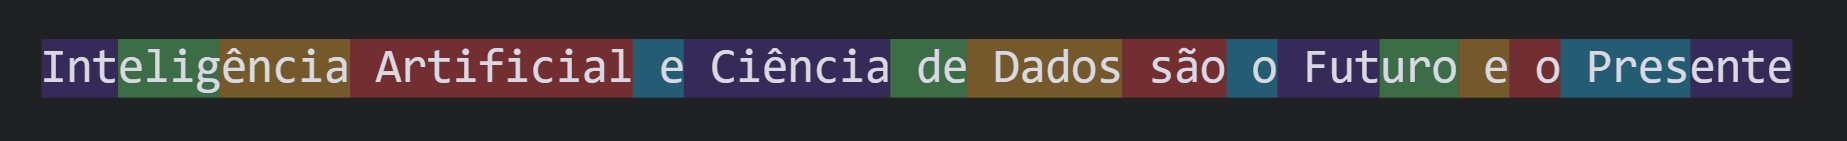</center>

Esta tokenização foi produzida usando a ferramenta online [OpenAI Tokenizer](https://platform.openai.com/tokenizer) que demonstra as diferentes formas de tokenização utilizadas em diferentes versões do ChatGPT.


In [ ]:
import tiktoken

enc = tiktoken.get_encoding("o200k_base")
token_ids = enc.encode(text)

# uso do str apenas para que a lista fique em uma linha
str(token_ids)

'[24912, 220, 27112, 220, 22420, 1193, 29414, 220, 290, 11931, 319, 10110, 382, 27005, 8908, 266, 185165, 452, 326, 290, 7848, 17736, 3911, 382, 337, 220, 220, 1179, 220, 504, 220]'


#### Lematização

A lematização é uma técnica que visa reduzir uma palavra a sua forma canônica, ou seja, a sua forma base, sendo esta também chamada de *lema*. Por exemplo, considere as palavras abaixo e seu *lema*:

\begin{array}{|c|ccccc|}
  \hline Palavras
  & Lema \\
  \hline
  going, went, gone     & go \\
  better , best, goodest  & good \\
  casas, casinha, casão & casa \\
  fazer , fazendo, fiz     & fazer \\
  \hline
\end{array}

Com esta técnica, o método passa a ser capaz de tratar variações de uma palavra como o mesmo termo.

Neste laboratório, será utilizado o *lematizador* da biblioteca `spaCy`. Esse lematizador utiliza um dicionário lexical e regras linguísticas para extrair os *lemas*. Como o método depende de informações que são específicas da língua do texto, é necessário fazer o download de modelos de processamento de texto para as línguas. As linhas a seguir demonstram como fazer o download para inglês e português.


In [ ]:
!python -m spacy download en_core_web_sm

################################################################################
# Para fazer o download das informações para português, use o comando abaixo.
################################################################################
# !python -m spacy download pt_core_news_sm


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ----- ---------------------------------- 1.8/12.8 MB 14.3 MB/s eta 0:00:01
     -------------------- ------------------- 6.6/12.8 MB 20.1 MB/s eta 0:00:01
     --------------------------------------  12.6/12.8 MB 23.9 MB/s eta 0:00:01
     --------------------------------------- 12.8/12.8 MB 22.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [ ]:

import spacy

LM = spacy.load("en_core_web_sm")

def lemmatization(text):
    # Realiza o processamento do texto, incluindo a
    # identificação dos lemmas das palavras.
    doc = LM(text)
    words = [word.lemma_ for word in doc if word.is_alpha]
    return words

words = lemmatization(text)

# uso do str apenas para que a lista fique em uma linha
str(words)

"['hello', 'mr', 'ray', 'feicao', 'the', 'restaurant', 'e', 'mail', 'be', 'chef', 'ratatouli', 'com', 'and', 'the', 'average', 'meal', 'price', 'be', 'u']"

**Importante**: Note que o lematizador da `spacy` já faz a tokenização por palavras.


#### Stemming

O stemming utiliza regras linguísticas para reduzir palavras flexionadas ou derivadas à sua raíz (*stem*). Diferente da lemmatização, essa redução ocorre pela remoção de sufixos e/ou prefixos das palavra e não considera o contexto de uso do termo.

A tabela abaixo ilustra algumas palavras abaixo e seu *stem*:

\begin{array}{|c|ccccc|}
  \hline Palavras
  & Stem \\
  \hline
  improving, improved, improvements    & improv \\
  working, work, works  & work \\
  estudando, estudar, estudei & estud \\
  brincando, brincar, brincou & brinc \\
  \hline
\end{array}

Os algoritmos de *stemming* também são dependentes da língua do texto. Neste laboratório será utilizado o *stemmer* de língua inglesa Porter, desenvolvido por Martin Porter [POR80]. O *stemmer* RSLP [ORE06] é bastante utilizado para português. Para visualizar o comportamento de diferentes métodos de stemming, veja este [site](http://text-processing.com/demo/stem/).


In [ ]:
from nltk.stem.porter import PorterStemmer

def stemming(words):
    porter = PorterStemmer()
    words = [porter.stem(word) for word in words]
    return words

words = stemming(words)
str(words)

"['hello', 'mr', 'ray', 'feicao', 'the', 'restaur', 'e', 'mail', 'be', 'chef', 'ratatouli', 'com', 'and', 'the', 'averag', 'meal', 'price', 'be', 'u']"

---


⚠️ **Atenção** ⚠️:
- Observe que a lematização produz palavras reais como resultado, enquanto algoritmos de *stemming* não.
- NÃO devem ser usados métodos de lematização junto com métodos de *stemming*! Use um ou outro.
- Métodos de lematização são preferíveis, mas possuem custo computacional substancialmente maior que métodos de *stemming*.


---


#### Remoção de stop-words

Stop-words são palavras que não agregam informação semântica ao texto, mas que aparecem com frequência, como artigos, preposições, conjunções e pronomes:

* Artigos: o, a , os, as, um, uns, uma, umas
* Preposições : a , ante, após, com, contra, de, desde ...
* Conjunções : que, se , mas, porém
* Pronomes: meu, seu, teu ...

A remoção de stop-words é importante pois reduz o vocabulário e evita que dois textos sejam classificados como sendo do mesmo tipo apenas porque compartilham muitas stop-words Para cada língua existem dicionários de stop-words. Nós vamos utilizar o dicionário existente na biblioteca *nltk*.

⚠️ **Atenção** ⚠️: Se a operação de stemming for utilizada, lembre-se de aplicar a transformação sobre a lista de stop-words também!


In [ ]:
import nltk

# faz o download da lista de stop words
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Windows\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [ ]:

from nltk.corpus import stopwords

def remove_stop_words(words):
  stop_words = set(stopwords.words('english'))
  # cria uma lista com as palavras w que não estão
  # no conjunto de stop words.
  words = [w for w in words if w not in stop_words]
  return words

words = remove_stop_words(words)
str(words)

"['hello', 'mr', 'ray', 'feicao', 'restaurant', 'e', 'mail', 'chef', 'ratatouli', 'com', 'average', 'meal', 'price', 'u']"

#### Consolidando os Conceitos

A função abaixo une as tranformações citadas anteriormente de forma que possamos facilmente aplicá-las aos nossos textos.

**Lembre-se**: Para cada tarefa, é importante revisitar as operações de preprocessamento e verificar quais fazem sentido para ela!

In [ ]:
def preprocessing(text):
  text = remove_accents(text)
  text = remove_tags(text)
  text = remove_non_alphanumeric(text)
  text = lowercasing(text)

  # use lemmatization ou stemming, não os dois
  words = lemmatization(text)
  # words = stemming(words)

  words = remove_stop_words(words)
  return words

text = "Hello, Mr. Ray Feição, the restaurant e-mail is chef@ratatouli.com and the average meal price is U$ 200.00."
words = preprocessing(text)

str(words)

"['hello', 'mr', 'ray', 'feicao', 'restaurant', 'e', 'mail', 'chef', 'ratatouli', 'com', 'average', 'meal', 'price', 'u']"

## Implementação dos Métodos

### Dataset


Para compreender o modelo de representação vetorial de documentos e como preprocessar textos, será utilizado um subconjunto da base de dados [IMDB Dataset of 50K Movie Reviews disponível no kaggle](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews). O dataset contém 50 mil críticas de filmes coletados do site IMDB. Cada crítica é classificada como positiva ou negativa. A tarefa é de análise de sentimentos, isto é, construir um classificador que receba como entrada uma das críticas e gere como saída uma classe informando se o texto enfatiza mais qualidades ou defeitos do filme.


#### Download e Exploração

O dataset está disponível no kaggle e vamos utilizar a biblioteca `kagglehub` para fazer o seu download. Como indicado abaixo, o dataset está armazenado em um arquivo `CSV` chamado `IMDB Dataset.csv` contendo os campos:
- `review`: texto da crítica
- `sentiment`: classificação como positiva ou negativa.

Observe que alguns textos possuem tags HTML que precisam ser removidas.

In [ ]:
import os
import pandas as pd
import kagglehub

path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
df = pd.read_csv(os.path.join(path, 'IMDB Dataset.csv'))
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


O gráfico abaixo mostra o número de documentos por classe. Podemos observar que o dataset é razoavelmente balanceado.

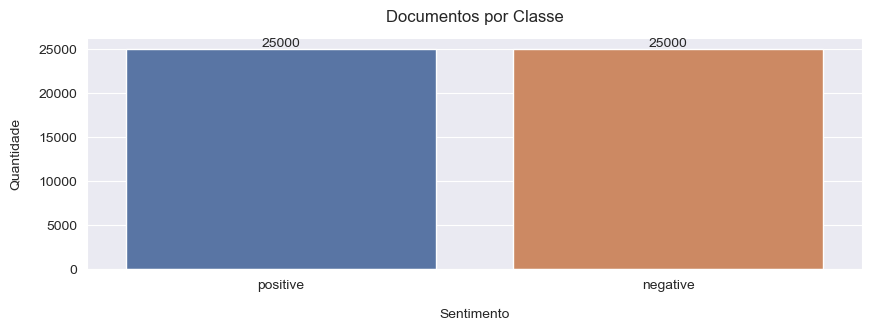

In [ ]:
#@title

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')


plt.figure(figsize=(10, 3))
ax = sns.countplot(x='sentiment', data=df, hue='sentiment', legend=False, palette="deep")
plt.title('Documentos por Classe', pad=12)
plt.xlabel('Sentimento', labelpad=12)
plt.ylabel('Quantidade', labelpad=12)

bars = ax.patches
# Put numbers of docs above bars
for bar in bars:
      height = int(bar.get_height())
      plt.text(bar.get_x() + bar.get_width()/2, height, height, ha='center', va='bottom')

plt.show()


#### Preprocessamento

---

O dataset apresenta uma quantitade grande de documentos e o seu preprocessamento pode demorar um pouco. Se preferir, use a célula abaixo para construir um dataset reduzido com um percentual do tamanho original. Naturalmente, a performance dos classificadores será inferior com menos dados.

In [ ]:
df = df.groupby('sentiment', group_keys=False).apply(lambda x: x.sample(frac=0.1, random_state=42))

C:\Users\Windows\AppData\Local\Temp\ipykernel_13360\4085370027.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('sentiment', group_keys=False).apply(lambda x: x.sample(frac=0.1, random_state=42))


---

O próximo passo é aplicar a função de preprocessamento para todos as linhas do dataframe.

🕓 *Esta operação pode demorar ~30min para ser executada com o dataset completo!*

In [ ]:
from tqdm.auto import tqdm

# Ativa o tqdm nas operações do pandas
tqdm.pandas()

# aplica a função a todas as linhas, mostrando uma barra de progresso
df['words'] = df['review'].progress_apply(preprocessing)
df

100%|██████████| 5000/5000 [02:28<00:00, 33.61it/s]


,Unnamed: 0,review,sentiment,words
32828,40282,I must preface this comment with a sort of adm...,negative,"[I, must, preface, comment, sort, admission, I..."
38995,43181,Did you ever watch a really bad movie and get ...,negative,"[ever, watch, really, bad, movie, get, mad, ev..."
10361,20327,I started to watch this movie with high expect...,negative,"[I, start, watch, movie, high, expectation, ho..."
46069,3796,"Well, this may be one of the worst movies ever...",negative,"[well, may, one, bad, movie, ever, atleast, ni..."
41456,39616,It must be a long time ago that I have seen su...,negative,"[must, long, time, ago, I, see, bad, movie, I,..."
...,...,...,...,...
37729,19434,Can any one help find out the title and artist...,positive,"[one, help, find, title, artist, song, play, l..."
48127,21803,"Tony Arzenta, a Sicilian hit-man or profession...",positive,"[tony, arzenta, sicilian, hit, man, profession..."
27941,37737,I was blown away by this film. I'm one of thos...,positive,"[I, blow, away, film, I, one, people, take, ri..."
1077,26732,"I loved this movie, it was cute and funny! Lau...",positive,"[I, love, movie, cute, funny, lauren, holly, w..."


Para evitar ter que realizar a operação acima novamente, vamos salvar o seu resultado.

In [ ]:
df.to_csv('imdb_preproc.csv')

Use a célula abaixo para carregar os dados preprocessados, se necessário.

In [ ]:
df = pd.read_csv('imdb_preproc-full.csv')
df['words'] = df['words'].apply(eval)   # transforma a lista de palavras de string para list
df

,Unnamed: 0,review,sentiment,words
0,32764,...and I Bought A Vampire Motorcycle staggers ...,negative,"[I, buy, vampire, motorcycle, stagger, line, l..."
1,20444,Jingofighter I agree with some of your comment...,positive,"[jingofighter, I, agree, comment, I, disagree,..."
2,26555,I watch a TON of movies and enjoy the occasion...,negative,"[I, watch, ton, movie, enjoy, occasional, b, m..."
3,24787,The photography of this bid-budget production ...,positive,"[photography, bid, budget, production, surpris..."
4,822,Wow! I picked this off the rental shelf becaus...,positive,"[wow, I, pick, rental, shelf, I, love, robert,..."
...,...,...,...,...
49995,28411,The Seven-Ups is a good and engrossing film. I...,positive,"[seven, good, engrossing, film, pack, credible..."
49996,21366,"Last Christmas, I was lucky enough to receive ...",positive,"[last, christmas, I, lucky, enough, receive, o..."
49997,12590,"Wow, after trashing the disk of Timo Roses ""Ro...",negative,"[wow, trash, disk, timo, rose, rout, city, min..."
49998,41048,It's been said that Batman Begins in the first...,positive,"[say, batman, begin, first, batman, movie, get..."


O gráfico abaixo mostra um historgrama do número de palavras por documento. A maioria dos documentos possuem poucas palavras e os 10 menores documentos possuem entre 3 e 7 palavras (após o preprocessamento).

Tamanho dos menores documentos: [4, 9, 10, 11, 11, 13, 14, 14, 14, 14]


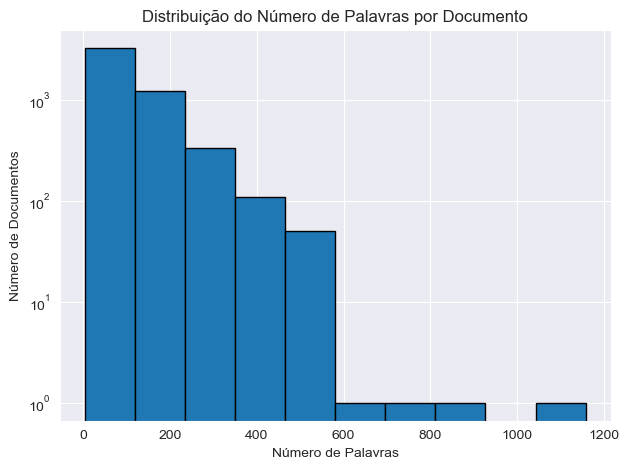

In [ ]:
#@title

doc_sizes = df["words"].apply(len)

print("Tamanho dos menores documentos:", sorted(doc_sizes)[:10])

plt.hist(
    doc_sizes,
    edgecolor="black",
)

plt.xlabel("Número de Palavras")
plt.ylabel("Número de Documentos")
plt.yscale('log')
plt.title("Distribuição do Número de Palavras por Documento")
plt.tight_layout()


### Construção da Representação Vetorial dos Documentos

O primeiro passo para construir a representação vetorial é identificar as palavras únicas que existem no corpus. Para isto, vamos iterar sobre as listas de palavras e adicioná-las em um estrutura de dados dicionário da linguagem Python. Esta estrutura de dados é implementada usando uma tabela hash o que garante que as operações de inserção e verificação de pertinência sejam feitas eficientemente.

No processo de construção do dicionário, vamos contar quantas vezes cada palavra aparece no corpus. Vamos iterar sobre as palavras dos documentos, se uma palavra ainda não existe no dicionário, adicionamos com frequência 0. Sempre que uma palavra é visitada, sua frequência é incrementada. Isto acontece inclusive na primeira vez, isto é, a frequência da palavra é inicializada com zero e a seguir incrementada para indicar que ela foi vista uma vez.

Ao final, o dicionário é transformado em uma lista que é ordenada pela frequência dos termos. Por fim, são exibidas as palavras mais frequentes e as menos frequentes.

In [ ]:
from pprint import pprint

word_dict = {}

for _, text in df.iterrows():
    for w in text.words:
        # adiciona a palavra no dicionario, se ela nao existe
        if w not in word_dict:
            word_dict[w] = 0

        # incrementa a contagem sempre que a palavra é encontrada
        word_dict[w] += 1

# Ordena pela frequencia
l = sorted(word_dict.items(), key=lambda x: x[1], reverse=True)

print('Número Total de Palavras:', len(word_dict))
print('-------------')

print('Palavras mais frequentes:')
pprint(l[:10])
print('-------------')

print('Palavras menos frequentes:')
pprint(l[-10:])


Número Total de Palavras: 30847
-------------
Palavras mais frequentes:
[('I', 19773),
 ('movie', 10412),
 ('film', 9646),
 ('one', 5628),
 ('see', 4886),
 ('make', 4517),
 ('like', 4388),
 ('good', 4196),
 ('get', 3441),
 ('well', 3256)]
-------------
Palavras menos frequentes:
[('blanc', 1),
 ('gravina', 1),
 ('filmedan', 1),
 ('bloodstained', 1),
 ('muerte', 1),
 ('tua', 1),
 ('costas', 1),
 ('mandylan', 1),
 ('housekeeping', 1),
 ('ilene', 1)]


Observe que várias palavras aparecem em apenas um documento e, por isto, não contribuem para a classificação dos documentos. Vamos descartar estas palavras.

In [ ]:
word_dict = {w: count for (w, count) in word_dict.items() if count > 1}

len(word_dict)

18345

---

⚠️ **Atenção** ⚠️: Lidar com dados textuais é uma atividade computacionalmente demandante. Note que estamos operando com uma base que em sua versão completa possui aproximadamente 50 mil documentos e 86 mil palavras diferentes e esta não é considerada uma base grande! Utilizar estruturas de dados adequadas é fundamental para evitar que as operações tomem um tempo excessivamente longo.

Para ilustrar este fato, a célula abaixo compara o tempo necessário para contar a frequência das palavras em alguns documentos usando os tipos lista e dicionário.

In [ ]:
from time import time

k = 1000

#####################
# Constroi o dicionario usando hash tables (set e dict em python)
#####################

start = time()

d = set()

for _, text in df.iloc[:k].iterrows():
    for w in text.words:
        if w not in d:
            d.add(w)

print(f"Tempo [set]: {time() - start:.3f}  segundos")

#####################
# Constroi o dicionario usando listas
#####################

start = time()

d = []

for _, text in df.iloc[:k].iterrows():
    for w in text.words:
        if w not in d:
            d.append(w)

print(f"Tempo [list]: {time() - start:.3f} segundos")


Tempo [set]: 0.079  segundos
Tempo [list]: 3.092 segundos


Utilizar o tipo `list` foi quase 60x mais lento que usar o tipo `set`! E quanto maior a quantidade de documentos iterados, maior é a diferença entre os dois.

---

Tendo o dicionário de palavras, o próximo passo é construir a matriz de frequências das palavras nos documentos.

Para isto, precisamos atribuir uma coluna para cada palavra. A célula abaixo constrói uma estrutura de dados dicionário associando palavras e um índice inteiro.

In [ ]:
words = list(word_dict.keys())

dictionary = {words[idx]: idx for idx in range(len(words))}

print(list(dictionary.items())[:10])
print(list(dictionary.items())[-10:])

[('I', 0), ('must', 1), ('preface', 2), ('comment', 3), ('sort', 4), ('admission', 5), ('suppose', 6), ('soft', 7), ('spot', 8), ('original', 9)]
[('zodiac', 18335), ('greenwich', 18336), ('dovetail', 18337), ('farmworker', 18338), ('construe', 18339), ('lawfully', 18340), ('orton', 18341), ('arzenta', 18342), ('duccio', 18343), ('tessari', 18344)]


Vamos embaralhar as linhas do dataframe para evitar que:
- ao fazer a divisão em conjuntos de treino e teste, um dos conjuntos fique com a maioria dos dados de uma classe.
- os classificadores sejam treinados com várias amostras da mesma classe em sequência.


In [ ]:
df = df.sample(frac=1)
df

,Unnamed: 0,review,sentiment,words
12794,23653,"""Tourist Trap"" is a genuinely spooky low-budge...",positive,"[tourist, trap, genuinely, spooky, low, budget..."
48170,40642,We now travel to a parallel universe where the...,negative,"[travel, parallel, universe, appearance, giant..."
8911,13253,Jack Lemmon and Walter Matthau began and endin...,positive,"[jack, lemmon, walter, matthau, begin, end, ca..."
22772,12950,The only problem with Married to the Mob is th...,positive,"[problem, married, mob, funny, dress, exactly,..."
33553,16528,Just plain good old stupid. <br /><br />I mean...,negative,"[plain, good, old, stupid, I, mean, really, st..."
...,...,...,...,...
21883,12994,The supposed writer and director Mr.Dhawan has...,negative,"[suppose, writer, director, mr, dhawan, copy, ..."
13935,23358,A MUST SEE documentary.-----This movie had so ...,positive,"[must, see, documentary, movie, many, thing, c..."
25394,18141,Head should have been a proud moment not just ...,positive,"[head, proud, moment, star, monkee, victor, ma..."
21335,22669,This is a great horror movie. Great Plot. And ...,positive,"[great, horror, movie, great, plot, person, fe..."


A célula abaixo constroi a matriz de frequências.
- É criada uma matriz com número de linhas igual ao número de documentos e número de colunas igual ao número de palavras.
- A matriz é preenchida inicialmente com zeros.
- Iteramos sobre os documentos e suas palavras.
- Para cada palavra, obtemos o número da sua coluna usando o dicionário (stop-words e palavras infrequentes que não existem no dicionário são ignoradas).
- Incrementamos a frequência da célula cuja linha é igual ao índice do documento e cuja coluna é igual ao índice da palavra.

In [ ]:
import numpy as np

counts = np.zeros((df.shape[0], len(dictionary)))

# para cada documento
for doc_idx, (_, row) in enumerate(df.iterrows()):
    # para cada palavra no documento
    for word in row.words:
        # se a palavra existe no dicionario
        if word in dictionary:
            # obtem o numero da coluna da palavra
            word_idx = dictionary[word]
            # incrementa a frequencia da palavra no documento
            counts[doc_idx, word_idx] += 1

counts.shape

(5000, 18345)

In [ ]:
counts

array([[0., 0., 0., ..., 0., 0., 0.],
       [2., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [3., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [4., 0., 0., ..., 0., 0., 0.]])

Podemos utilizar a biblioteca `scikit-learn` para obter a representação vetorial usando TF-IDF. Por padrão, a biblioteca normaliza as linhas usando **norma-L2**, isto é, a soma dos elementos ao quadrado de cada linha passa a ser 1.

In [ ]:
from sklearn.feature_extraction.text import TfidfTransformer

transf = TfidfTransformer()
tfidf = transf.fit_transform(counts).toarray()
tfidf

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.01486377, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.03482744, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.13192815, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.16250146, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

### Treinamento dos Classificadores

Vamos comparar a performance dos classificadores usando as duas representações de documentos.

Como preparação para isto, vamos transformar os sentimentos em valores inteiros usando a classe `LabelEncoder`.


In [ ]:
from sklearn.preprocessing import LabelEncoder

y = LabelEncoder().fit_transform(df['sentiment'])
y

array([1, 0, 1, ..., 1, 1, 0])

A seguir, normalizamos os vetores da representação por BoW (frequência dos termos) dividindo pelo valor máximo da matriz.


In [ ]:
x_bow = counts / counts.max()
x_bow

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.04761905, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.07142857, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.02380952, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.0952381 , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

Por fim, são separados conjuntos de treino (70%) e teste (30%).


In [ ]:

n = int(len(df) * 0.7)

x_bow_train = x_bow[:n]
x_tfidf_train = tfidf[:n]
y_train = y[:n]

x_bow_test = x_bow[n:]
x_tfidf_test = tfidf[n:]
y_test = y[n:]

print("x_bow_train.shape:", x_bow_train.shape)
print("x_bow_test.shape:", x_bow_test.shape)


x_bow_train.shape: (3500, 18345)
x_bow_test.shape: (1500, 18345)


Verifica se a distribuição de labels está fazendo sentido nos conjuntos de treino e teste.

In [ ]:
print(np.unique(y_train, return_counts=True))
print(np.unique(y_test, return_counts=True))

(array([0, 1]), array([1748, 1752], dtype=int64))
(array([0, 1]), array([752, 748], dtype=int64))


Treinamento e avaliação dos classificadores para a representação vetorial com BoW.

🕓 *Esta célula pode demorar bastante (horas) para ser executada com o dataset completo!*

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

names = [
    "KNN",
    "Linear Classifier",
    "Random Forest",
    "Neural Net",
]

result = []

classifiers = [
    KNeighborsClassifier(5, metric='cosine'),
    LogisticRegression(solver='saga', max_iter=500),
    RandomForestClassifier(),
    MLPClassifier(hidden_layer_sizes=(128, 128)),
]

for idx in tqdm(range(len(names))):
    name = names[idx]
    clf = classifiers[idx]
    clf.fit(x_bow_train, y_train)

    y_train_pred = clf.predict(x_bow_train)
    y_test_pred = clf.predict(x_bow_test)

    train_prc, train_rcl, train_f1, _ = precision_recall_fscore_support(y_train, y_train_pred, average='macro', zero_division=0.0)
    train_acc = accuracy_score(y_train, y_train_pred)

    test_prc, test_rcl, test_f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average='macro', zero_division=0.0)
    test_acc = accuracy_score(y_test, y_test_pred)

    result.append({
        "classifier": name,
        "train_prc": train_prc,
        "train_rcl": train_rcl,
        "train_f1": train_f1,
        "train_acc": train_acc,
        "test_prc": test_prc,
        "test_rcl": test_rcl,
        "test_f1": test_f1,
        "test_acc": test_acc,
    })


pd.DataFrame(result)

100%|██████████| 4/4 [01:33<00:00, 23.40s/it]


,classifier,train_prc,train_rcl,train_f1,train_acc,test_prc,test_rcl,test_f1,test_acc
0,KNN,0.795773,0.795722,0.795707,0.795714,0.666300,0.665939,0.665797,0.666000
1,Linear Classifier,0.832809,0.830525,0.830272,0.830571,0.788620,0.782857,0.781617,0.782667
2,Random Forest,1.000000,1.000000,1.000000,1.000000,0.826064,0.825396,0.825254,0.825333
3,Neural Net,1.000000,1.000000,1.000000,1.000000,0.849402,0.848728,0.848602,0.848667


Treinamento e avaliação dos classificadores para a representação vetorial com TF-IDF.

🕓 *Esta célula pode demorar bastante para ser executada com o dataset completo!*

In [ ]:

classifiers = [
    KNeighborsClassifier(5, metric='cosine'),
    LogisticRegression(solver='saga', max_iter=500),
    RandomForestClassifier(),
    MLPClassifier(hidden_layer_sizes=(128, 128)),
]

result = []

for idx in tqdm(range(len(names))):
    name = names[idx]
    clf = classifiers[idx]

    clf.fit(x_tfidf_train, y_train)

    y_train_pred = clf.predict(x_tfidf_train)
    y_test_pred = clf.predict(x_tfidf_test)

    train_prc, train_rcl, train_f1, _ = precision_recall_fscore_support(y_train, y_train_pred, average='macro')
    train_acc = accuracy_score(y_train, y_train_pred)

    test_prc, test_rcl, test_f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average='macro')
    test_acc = accuracy_score(y_test, y_test_pred)

    result.append({
        "classifier": name,
        "train_prc": train_prc,
        "train_rcl": train_rcl,
        "train_f1": train_f1,
        "train_acc": train_acc,
        "test_prc": test_prc,
        "test_rcl": test_rcl,
        "test_f1": test_f1,
        "test_acc": test_acc,
    })


pd.DataFrame(result)

100%|██████████| 4/4 [01:07<00:00, 16.85s/it]


,classifier,train_prc,train_rcl,train_f1,train_acc,test_prc,test_rcl,test_f1,test_acc
0,KNN,0.833624,0.833121,0.833076,0.833143,0.715013,0.713449,0.712843,0.713333
1,Linear Classifier,0.953664,0.953416,0.953422,0.953429,0.858985,0.854157,0.853530,0.854000
2,Random Forest,1.000000,1.000000,1.000000,1.000000,0.833385,0.833350,0.833331,0.833333
3,Neural Net,1.000000,1.000000,1.000000,1.000000,0.844335,0.844042,0.843972,0.844000


Analisando os resultados, vemos que o uso de TF-IDF foi benéfico nesta tarefa e que a rede neural e o classificador linear apresentaram as melhores performances.

## Referências

- [BAE13] Baeza-Yates, R., & Ribeiro-Neto, B. (2013). Recuperação de Informação-: Conceitos e Tecnologia das Máquinas de Busca. Bookman Editora.

- [BIR09] Bird, S., Klein, E., & Loper, E. (2009). Natural language processing with Python: analyzing text with the natural language toolkit. " O'Reilly Media, Inc.". Disponível em: https://thuvienso.dau.edu.vn:88/bitstream/DHKTDN/6460/1/Natural%20Language%20Processing%20with%20Python.4149.pdf.

- [POR80] Porter, M. F. (1980). An algorithm for suffix stripping. Program, 14(3), 130-137.

- [ORE06] Orengo, V. M., Buriol, L. S., & Coelho, A. R. (2006, September). A study on the use of stemming for monolingual ad-hoc Portuguese information retrieval. In Workshop of the Cross-Language Evaluation Forum for European Languages (pp. 91-98). Berlin, Heidelberg: Springer Berlin Heidelberg.

- [SEM21] Semantix. (2021). TF-IDF: Entenda o que é Frequency Inverse Document Frequency. Disponível em: https://semantix.ai/tf-idf-entenda-o-que-e-frequency-inverse-document-frequency/.

- [DAV20] Davedovicz, G. (2020). NLP para Iniciantes: Lematização. Disponível em: https://medium.com/@guilherme.davedovicz/nlp-para-iniciantes-lematiza%C3%A7%C3%A3o-d3f723fa9ee3.

- [SPI22] Spot Intelligence. (2022). Lemmatization in NLP: Techniques and Tools. Disponível em: https://spotintelligence.com/2022/12/09/lemmatization/#2_SpaCy_Lemmatizer.
